# Logic & Knowledge Representation — Rules Engine Demo
**CIC6314 Artificial Intelligence — Smart Product Recommendation System**  
**Member 2 — Rules Engine** | Dataset: UCI Online Retail

This notebook demonstrates the knowledge-based rules engine (`src/rules_engine.py`) that acts as the **first stage** of the recommendation pipeline.

The rules engine applies **10 hand-crafted heuristic rules** to every customer profile to determine which product categories they are eligible to receive recommendations for.

---

## Pipeline Position

```
User Profile
     ↓
[Rules Engine]  ← YOU ARE HERE
  apply_rules(profile) → eligible categories
     ↓
[Search Module] → BFS narrowing
     ↓
[ML Model] → personalised scoring
     ↓
[Integration] → final output
```

In [6]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.constants import PRODUCT_CATEGORIES, SAMPLE_PROFILES
from src.rules_engine import apply_rules

print("✓ Rules engine loaded")
print(f"✓ {len(PRODUCT_CATEGORIES)} product categories:")
for i, cat in enumerate(PRODUCT_CATEGORIES, 1):
    print(f"  {i}. {cat}")

✓ Rules engine loaded
✓ 8 product categories:
  1. Home Decor
  2. Kitchen & Dining
  3. Seasonal & Gifts
  4. Toys & Games
  5. Stationery & Craft
  6. Fashion & Accessories
  7. Garden & Outdoor
  8. Food & Confectionery


## 1. The 10 Rules

The rules engine implements **10 behavioural heuristics** divided into two groups:

### Group A — Spend Tier Rules (Rules 1–4)
Restrict category access based on the customer's spending bracket, reducing the risk of recommending products outside their budget.

| Rule | Trigger | Categories Unlocked |
|------|---------|-------------------|
| Rule 1 | `price_range == 'Low'` | Home Decor, Stationery & Craft, Seasonal & Gifts |
| Rule 2 | `price_range == 'Mid-Low'` | Home Decor, Kitchen & Dining, Seasonal & Gifts, Fashion & Accessories |
| Rule 3 | `price_range == 'Mid-High'` | Kitchen & Dining, Home Decor, Toys & Games, Garden & Outdoor |
| Rule 4 | `price_range == 'High'` | All 8 categories |

### Group B — Behavioural Rules (Rules 5–10)
Dynamically expand or restrict based on purchase behaviour and loyalty signals.

| Rule | Trigger | Effect |
|------|---------|--------|
| Rule 5 | Has `favourite_category` | Always include their primary category |
| Rule 6 | Bought from 3+ categories | Open full catalogue (broad explorer) |
| Rule 7 | Bought from exactly 1 category | Restrict to favourite + 1 ALS neighbour |
| Rule 8 | Inactive 90+ days | Add Seasonal & Gifts, Food & Confectionery (re-engagement) |
| Rule 9 | `customer_segment == 'Frequent'` | Open full catalogue |
| Rule 10 | `customer_segment == 'New'` | **Override all** → top 3 popular only |

In [7]:
def trace_rules(profile):
    """Show which rules fired and why for a given profile."""
    price_range    = profile.get('price_range')
    fav            = profile.get('favourite_category')
    purchased_cats = profile.get('purchased_categories', [])
    segment        = profile.get('customer_segment')
    recency        = profile.get('recency_days', 0)

    fired = []
    if price_range == 'Low':       fired.append(('Rule 1', f'price_range={price_range} → Low spend tier'))
    if price_range == 'Mid-Low':   fired.append(('Rule 2', f'price_range={price_range} → Mid-Low spend tier'))
    if price_range == 'Mid-High':  fired.append(('Rule 3', f'price_range={price_range} → Mid-High spend tier'))
    if price_range == 'High':      fired.append(('Rule 4', f'price_range={price_range} → High spend tier'))
    if fav:                        fired.append(('Rule 5', f'favourite_category={fav}'))
    if len(purchased_cats) >= 3:   fired.append(('Rule 6', f'{len(purchased_cats)} categories purchased → full catalogue'))
    if len(purchased_cats) == 1:   fired.append(('Rule 7', f'Only 1 category purchased → focused buyer'))
    if recency > 90:               fired.append(('Rule 8', f'recency_days={recency} > 90 → re-engagement'))
    if segment == 'Frequent':      fired.append(('Rule 9', f'segment=Frequent → power shopper'))
    if segment == 'New':           fired.append(('Rule 10', f'segment=New → cold-start override'))
    return fired

print("✓ Rule tracer ready")

✓ Rule tracer ready


## 2. Running All 5 Sample Profiles

Applying `apply_rules()` to each of the 5 customer profiles defined in `src/constants.py`.

In [8]:
print("=" * 70)
print("  RULES ENGINE — Full Demo on All 5 Sample Profiles")
print("=" * 70)

for name, profile in SAMPLE_PROFILES.items():
    print(f"\n{'─'*70}")
    print(f"  Profile   : {name}")
    print(f"  Segment   : {profile['customer_segment']}")
    print(f"  Spend     : {profile['price_range']}")
    print(f"  Recency   : {profile['recency_days']} days")
    print(f"  Favourite : {profile['favourite_category']}")
    print(f"  Categories bought: {profile['purchased_categories']}")
    
    fired = trace_rules(profile)
    print(f"\n  Rules fired ({len(fired)}):")
    for rule, reason in fired:
        print(f"    ✓ {rule}: {reason}")
    
    eligible = apply_rules(profile)
    print(f"\n  Eligible categories ({len(eligible)}/8):")
    for cat in eligible:
        print(f"    → {cat}")

print(f"\n{'='*70}")

  RULES ENGINE — Full Demo on All 5 Sample Profiles

──────────────────────────────────────────────────────────────────────
  Profile   : gift_buyer
  Segment   : Occasional
  Spend     : Low
  Recency   : 24 days
  Favourite : Seasonal & Gifts
  Categories bought: ['Seasonal & Gifts', 'Garden & Outdoor', 'Kitchen & Dining']

  Rules fired (3):
    ✓ Rule 1: price_range=Low → Low spend tier
    ✓ Rule 5: favourite_category=Seasonal & Gifts
    ✓ Rule 6: 3 categories purchased → full catalogue

  Eligible categories (8/8):
    → Home Decor
    → Kitchen & Dining
    → Seasonal & Gifts
    → Toys & Games
    → Stationery & Craft
    → Fashion & Accessories
    → Garden & Outdoor
    → Food & Confectionery

──────────────────────────────────────────────────────────────────────
  Profile   : home_decorator
  Segment   : Frequent
  Spend     : Low
  Recency   : 20 days
  Favourite : Home Decor
  Categories bought: ['Home Decor', 'Food & Confectionery']

  Rules fired (3):
    ✓ Rule 1: pric

## 3. Summary Table

In [9]:
print(f"{'Profile':<22} {'Segment':<12} {'Spend':<10} {'Rules':<8} {'Eligible':<5} Categories")
print("─" * 90)

for name, profile in SAMPLE_PROFILES.items():
    fired   = trace_rules(profile)
    eligible = apply_rules(profile)
    rules_str = ", ".join(r for r, _ in fired)
    cats_str  = ", ".join(eligible)
    print(f"{name:<22} {profile['customer_segment']:<12} {profile['price_range']:<10} {rules_str:<8} {len(eligible):<5} {cats_str}")

Profile                Segment      Spend      Rules    Eligible Categories
──────────────────────────────────────────────────────────────────────────────────────────
gift_buyer             Occasional   Low        Rule 1, Rule 5, Rule 6 8     Home Decor, Kitchen & Dining, Seasonal & Gifts, Toys & Games, Stationery & Craft, Fashion & Accessories, Garden & Outdoor, Food & Confectionery
home_decorator         Frequent     Low        Rule 1, Rule 5, Rule 9 8     Home Decor, Kitchen & Dining, Seasonal & Gifts, Toys & Games, Stationery & Craft, Fashion & Accessories, Garden & Outdoor, Food & Confectionery
kitchen_enthusiast     Frequent     Mid-Low    Rule 2, Rule 5, Rule 6, Rule 8, Rule 9 8     Home Decor, Kitchen & Dining, Seasonal & Gifts, Toys & Games, Stationery & Craft, Fashion & Accessories, Garden & Outdoor, Food & Confectionery
craft_lover            Occasional   Low        Rule 1, Rule 5, Rule 6, Rule 8 8     Home Decor, Kitchen & Dining, Seasonal & Gifts, Toys & Games, Stationery 

## 4. Visualisation — Eligible Categories per Profile

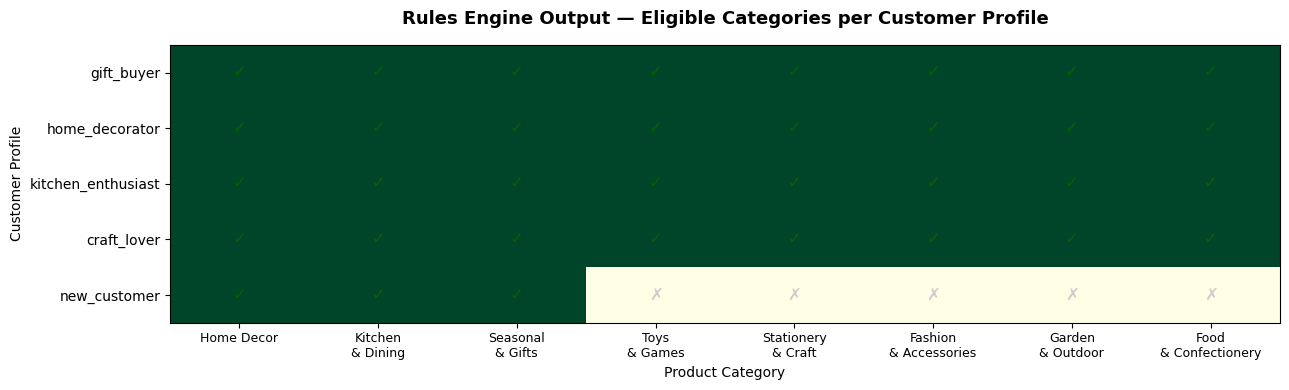

✓ Saved: notebooks/fig_rules_heatmap.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

profiles_list = list(SAMPLE_PROFILES.items())
profile_names = [n for n, _ in profiles_list]
eligible_sets = [set(apply_rules(p)) for _, p in profiles_list]

# Build heatmap matrix: rows=profiles, cols=categories
matrix = np.zeros((len(profile_names), len(PRODUCT_CATEGORIES)))
for i, elig in enumerate(eligible_sets):
    for j, cat in enumerate(PRODUCT_CATEGORIES):
        if cat in elig:
            matrix[i][j] = 1

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(matrix, cmap='YlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(PRODUCT_CATEGORIES)))
ax.set_xticklabels([c.replace(' & ', '\n& ') for c in PRODUCT_CATEGORIES], fontsize=9)
ax.set_yticks(range(len(profile_names)))
ax.set_yticklabels(profile_names, fontsize=10)

for i in range(len(profile_names)):
    for j in range(len(PRODUCT_CATEGORIES)):
        ax.text(j, i, '✓' if matrix[i][j] else '✗',
                ha='center', va='center',
                color='darkgreen' if matrix[i][j] else '#ccc', fontsize=12)

ax.set_title('Rules Engine Output — Eligible Categories per Customer Profile', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Product Category', fontsize=10)
ax.set_ylabel('Customer Profile', fontsize=10)
plt.tight_layout()
plt.savefig('fig_rules_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: notebooks/fig_rules_heatmap.png")

## 5. Rule Coverage Analysis

How many rules fire per profile, and how many categories each rule combination produces.

In [11]:
print("Rule Coverage Analysis")
print("─" * 50)
for name, profile in SAMPLE_PROFILES.items():
    fired    = trace_rules(profile)
    eligible = apply_rules(profile)
    print(f"\n{name}:")
    print(f"  Rules fired  : {len(fired)}")
    print(f"  Eligible cats: {len(eligible)}/8")
    print(f"  Coverage     : {len(eligible)/8*100:.0f}%")

Rule Coverage Analysis
──────────────────────────────────────────────────

gift_buyer:
  Rules fired  : 3
  Eligible cats: 8/8
  Coverage     : 100%

home_decorator:
  Rules fired  : 3
  Eligible cats: 8/8
  Coverage     : 100%

kitchen_enthusiast:
  Rules fired  : 5
  Eligible cats: 8/8
  Coverage     : 100%

craft_lover:
  Rules fired  : 4
  Eligible cats: 8/8
  Coverage     : 100%

new_customer:
  Rules fired  : 2
  Eligible cats: 3/8
  Coverage     : 38%


## 6. Integration with the Rest of the Pipeline

The output of `apply_rules()` feeds directly into the search module:

```python
# In career_recommender.ipynb (Member 4 — Integration)

eligible = apply_rules(user_profile)          # ← THIS NOTEBOOK'S OUTPUT

if not user_profile['purchase_history']:
    # Cold-start path
    categories = find_popular_categories(eligible, price_range)
else:
    # Personalised path  
    shortlist  = find_reachable_categories(user_profile, eligible)  # BFS on eligible
    categories = predict_product(user_profile, candidates=shortlist) # ML scoring
```

**Key guarantees this module provides:**
1. Output is always a non-empty list
2. All returned strings are valid `PRODUCT_CATEGORIES` values
3. Order matches canonical `PRODUCT_CATEGORIES` order (deterministic)
4. Rule 10 (New customer) **overrides** all other rules — cold-start is always isolated

## Summary

| Criterion | Detail |
|---|---|
| Number of rules | **10** (4 spend-tier + 6 behavioural) |
| Inference mechanism | Forward-chaining heuristics on profile features |
| Cold-start handling | Rule 10 overrides all — routes to popularity baseline |
| Output guarantee | Always returns 1–8 categories from `PRODUCT_CATEGORIES` |
| Integration point | Output passed directly to `find_reachable_categories()` |